In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight",
           "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
           "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
           "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=columns, na_values="?")

df.dropna(subset=['price'], inplace=True)
df['normalized-losses'] = df['normalized-losses'].fillna(df['normalized-losses'].mean())
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])
df['bore'] = df['bore'].fillna(df['bore'].mean())
df['stroke'] = df['stroke'].fillna(df['stroke'].mean())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
df['peak-rpm'] = df['peak-rpm'].fillna(df['peak-rpm'].mean())

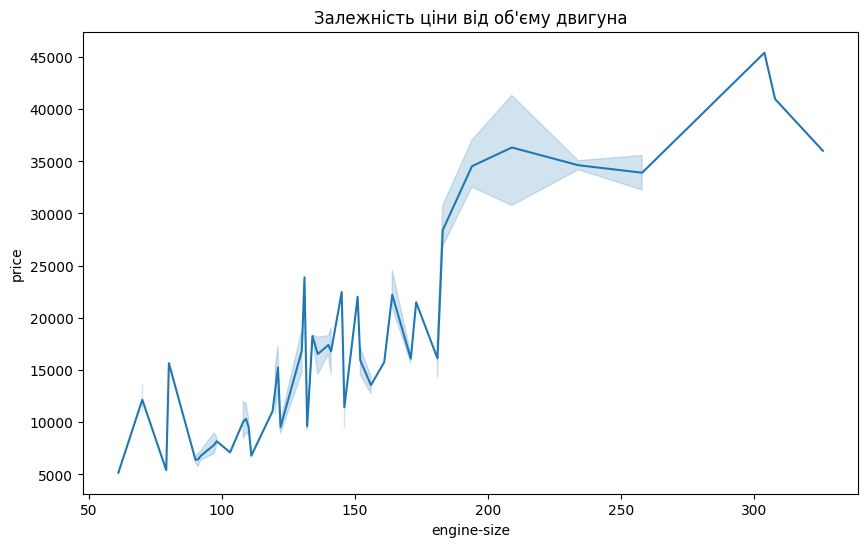

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df['engine-size'], y=df['price'])
plt.title("Залежність ціни від об'єму двигуна")
plt.show()

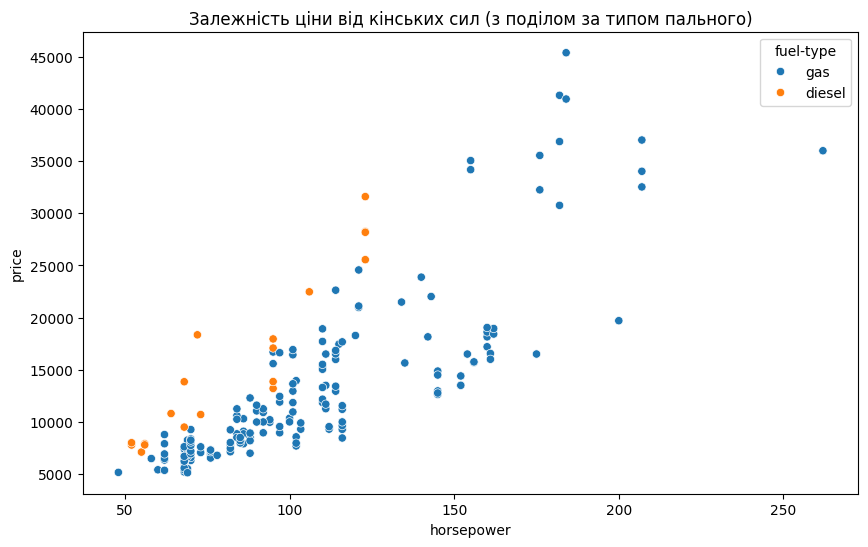

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['horsepower'], y=df['price'], hue=df['fuel-type'])
plt.title("Залежність ціни від кінських сил (з поділом за типом пального)")
plt.show()

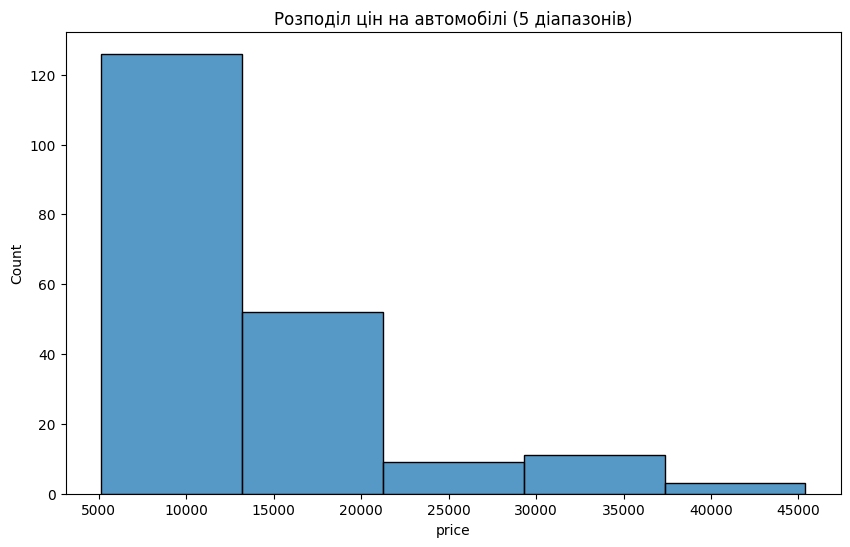

In [7]:
plt.figure(figsize=(10, 6))
bins = np.linspace(df['price'].min(), df['price'].max(), 6)
sns.histplot(df['price'], bins=bins)
plt.title("Розподіл цін на автомобілі (5 діапазонів)")
plt.show()

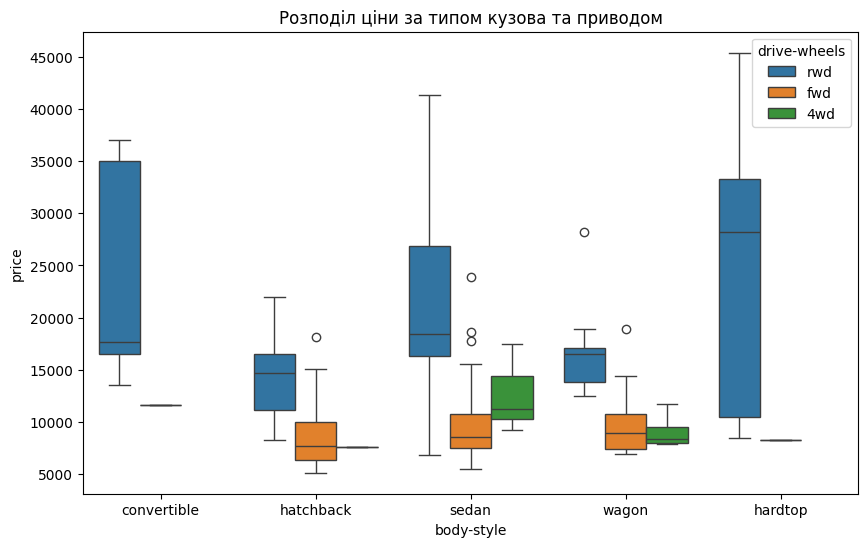

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['body-style'], y=df['price'], hue=df['drive-wheels'])
plt.title("Розподіл ціни за типом кузова та приводом")
plt.show()

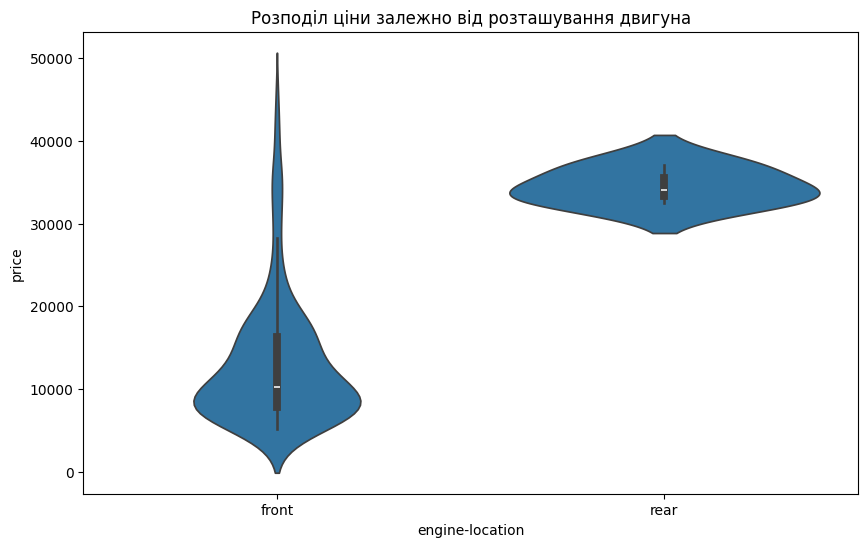

In [9]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['engine-location'], y=df['price'])
plt.title("Розподіл ціни залежно від розташування двигуна")
plt.show()

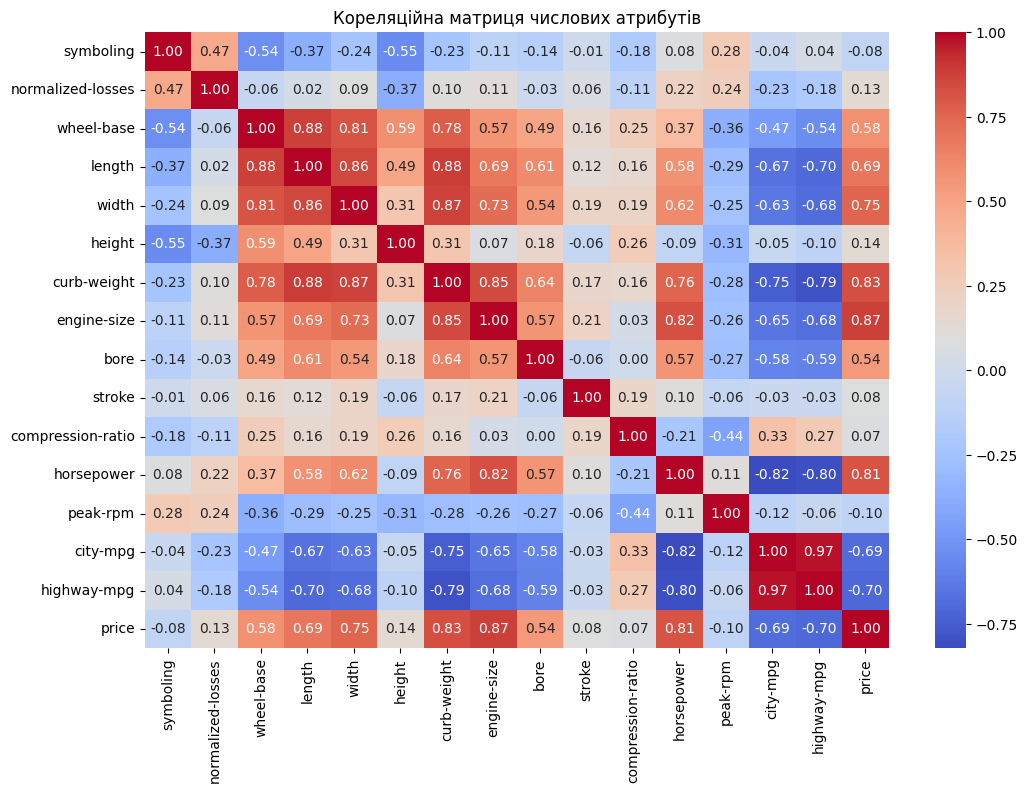

In [10]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляційна матриця числових атрибутів")
plt.show()

<Figure size 1000x600 with 0 Axes>

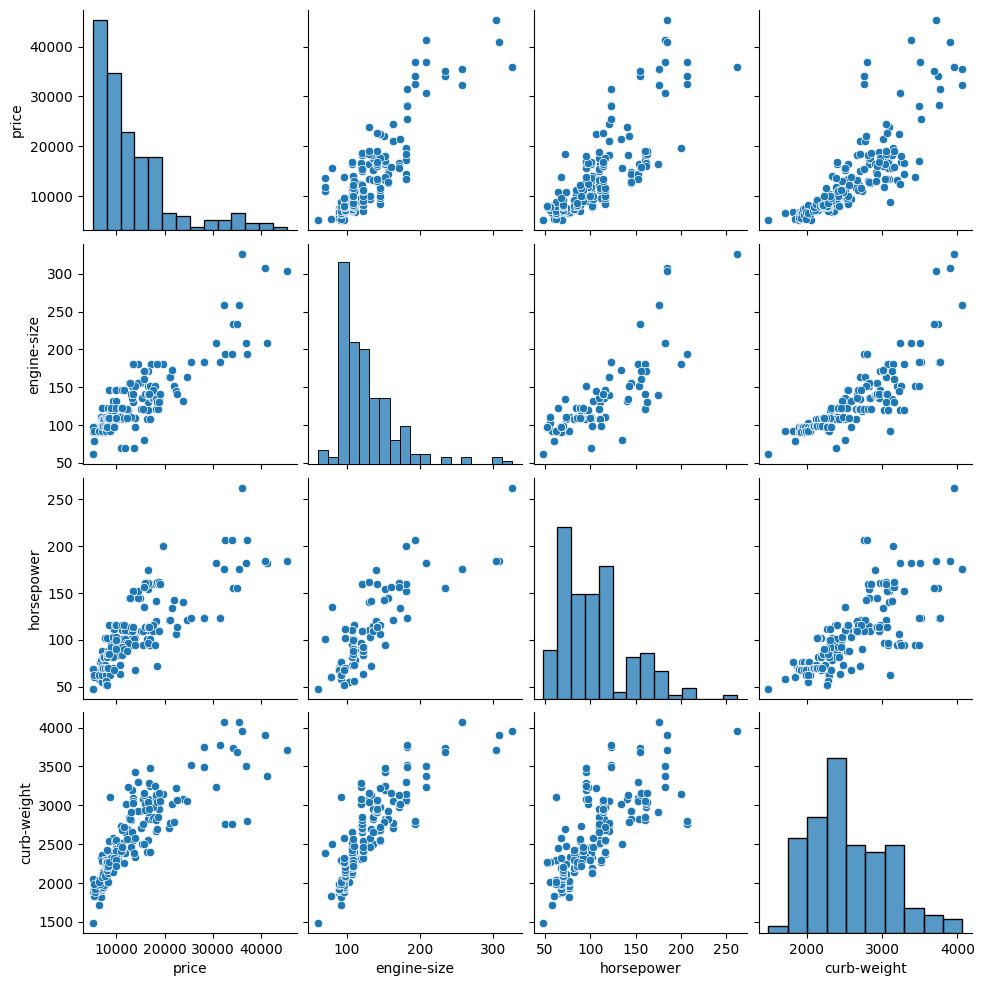

In [11]:
plt.figure(figsize=(10, 6))
sns.pairplot(df[['price', 'engine-size', 'horsepower', 'curb-weight']])
plt.show()